# Pythonセミナー第5回：糖尿病データのクラス分類

`diabetes.csv`を用いて、k近傍法（kNN）とRandom Forestによる糖尿病のクラス分類を行う。各手法について、デフォルト設定と5分割交差検証（CV）によるハイパーパラメータチューニング後の性能を比較する。

- 目的変数：`Outcome`（0: 陰性、1: 陽性）
- モデル選択指標：陽性クラスのF1スコア
- 最終評価：学習に使わない固定テストデータ
- 参考：`sample_program_4_9.py`（kNNとオートスケーリング）、`sample_program_4_14.py`（Random Forestと特徴量重要度）

In [1]:
# グラフを作成・表示するためのライブラリ
import matplotlib.pyplot as plt
# 数値計算や配列操作を行うためのライブラリ
import numpy as np
# 表形式データの読み込み・加工・分析を行うためのライブラリ
import pandas as pd
# Jupyter Notebook上にMarkdownや表を表示するための機能
from IPython.display import Markdown, display
# ランダムフォレストによる分類モデル
from sklearn.ensemble import RandomForestClassifier
# 分類モデルの性能を評価する指標とグラフ
from sklearn.metrics import (
    ConfusionMatrixDisplay,  # 混同行列を表示
    PrecisionRecallDisplay,  # Precision-Recall曲線を表示
    RocCurveDisplay,  # ROC曲線を表示
    accuracy_score,  # 正解率を計算
    f1_score,  # F1スコアを計算
    precision_score,  # 適合率を計算
    recall_score,  # 再現率を計算
    roc_auc_score,  # ROC-AUCを計算
)
# データ分割・交差検証・パラメータ探索に使う機能
from sklearn.model_selection import (
    GridSearchCV,  # 最適なパラメータを総当たりで探索
    StratifiedKFold,  # クラス比率を保って交差検証用データを分割
    cross_val_score,  # 交差検証の評価値を計算
    train_test_split,  # 学習用とテスト用にデータを分割
)
# k近傍法による分類モデル
from sklearn.neighbors import KNeighborsClassifier
# 前処理とモデルを一連の処理としてまとめる機能
from sklearn.pipeline import Pipeline
# 特徴量を平均0・標準偏差1に標準化する機能
from sklearn.preprocessing import StandardScaler

# 乱数を固定して、実行するたびに同じ結果を得られるようにする
RANDOM_STATE = 42
# グラフを白い背景とグリッドのスタイルで表示する
plt.style.use("seaborn-v0_8-whitegrid")
# DataFrameの全ての列を省略せずに表示する
pd.set_option("display.max_columns", None)

## 1. データの確認


In [2]:
# CSVファイルを読み込み、datasetというDataFrameに格納する
dataset = pd.read_csv("diabetes.csv")
# データの先頭5行を表示する
display(dataset.head())

# データ数と、目的変数Outcomeを除いた説明変数の数を表示する
print(f"データ数: {dataset.shape[0]}")
print(f"説明変数数: {dataset.shape[1] - 1}")
# Outcomeのクラス別件数を表示する
print("\nクラス数:")
display(dataset["Outcome"].value_counts().sort_index().rename("count").to_frame())
# 各列に0がいくつ含まれているかを確認する
print("各列に含まれる0の数:")
display((dataset == 0).sum().rename("zero_count").to_frame().T)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


データ数: 768
説明変数数: 8

クラス数:


,count
Outcome,
0,500
1,268


各列に含まれる0の数:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
zero_count,111,5,35,227,374,11,0,0,500


In [3]:
# Outcome以外を説明変数X、Outcomeを目的変数yに分ける
X = dataset.drop(columns="Outcome")
y = dataset["Outcome"]

# クラス比率を保ちながら、データを学習用80%とテスト用20%に分割する
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

# クラス比率を保つ5分割交差検証を設定する
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 学習用・テスト用データの件数と陽性率を表にまとめる
split_summary = pd.DataFrame(
    {
        "samples": [len(y_train), len(y_test)],
        "positive_rate": [y_train.mean(), y_test.mean()],
    },
    index=["train", "test"],
)
# 陽性率を小数点以下3桁で表示する
display(split_summary.style.format({"positive_rate": "{:.3f}"}))

,samples,positive_rate
train,614,0.349
test,154,0.351


## 2. k近傍法（kNN）

### 原理と特徴

kNNは、予測対象に距離が近い学習サンプルを$k$個探し、その多数決でクラスを決める。明示的な数式モデルを仮定せず、非線形な境界も表現できる。一方、予測時に学習データとの距離計算が必要で、データ数や説明変数が増えると計算量が増える。

距離に基づくため、値のスケールが大きい変数が距離を支配する。そこで`sample_program_4_9.py`と同様に標準化を行う。本ノートブックでは標準化を`Pipeline`内に置き、各CVの検証データの情報が標準化へ混入しないようにする。

### 主要なハイパーパラメータ

- `n_neighbors`：小さいと複雑な境界になって過学習しやすく、大きいと平滑になりすぎて未学習になりやすい。
- `weights`：`uniform`は全近傍を同じ重み、`distance`は近いサンプルを重く扱う。後者は局所構造を反映しやすい。
- `p`：Minkowski距離の次数。`p=1`はマンハッタン距離、`p=2`はユークリッド距離であり、近傍関係が変化する。

In [4]:
# 標準化してからデフォルト設定のkNNで分類するパイプラインを作る
knn_default = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier()),
    ]
)

# 学習データに対して5分割交差検証を行い、F1スコアを計算する
knn_default_cv_scores = cross_val_score(
    knn_default, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
)
# 全学習データを使ってkNNモデルを学習する
knn_default.fit(X_train, y_train)

# モデルの設定と交差検証F1の平均・標準偏差を表示する
print("kNN デフォルト設定:", knn_default.named_steps["model"].get_params())
print(f"5-fold CV F1: {knn_default_cv_scores.mean():.3f} ± {knn_default_cv_scores.std():.3f}")

kNN デフォルト設定: {'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': None, 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
5-fold CV F1: 0.588 ± 0.027


In [5]:
# kNNで探索する近傍数・重み・距離の種類を指定する
knn_param_grid = {
    "model__n_neighbors": list(range(3, 32, 2)),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2],
}

# 各パラメータの組み合わせを5分割交差検証し、F1が最大の設定を探す
knn_grid = GridSearchCV(
    estimator=Pipeline(
        [("scaler", StandardScaler()), ("model", KNeighborsClassifier())]
    ),
    param_grid=knn_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
# 学習データを使ってパラメータ探索を実行する
knn_grid.fit(X_train, y_train)
# 最良パラメータで学習されたkNNモデルを取り出す
knn_tuned = knn_grid.best_estimator_

# 選ばれたパラメータと交差検証F1を表示する
print("kNN 最良パラメータ:", knn_grid.best_params_)
print(f"kNN 最良CV F1: {knn_grid.best_score_:.3f}")

kNN 最良パラメータ: {'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'uniform'}
kNN 最良CV F1: 0.609


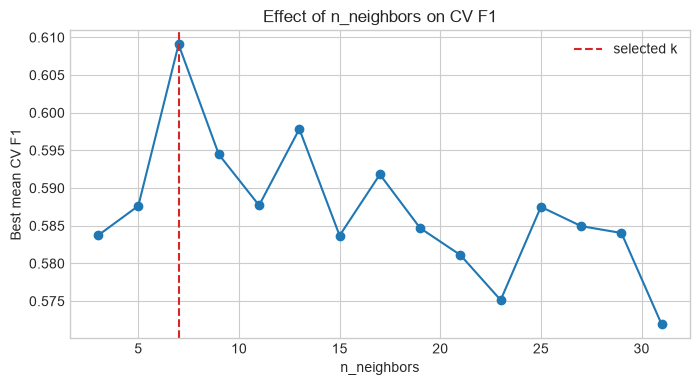

In [6]:
# kNNのパラメータ探索結果をDataFrameに変換する
knn_cv_results = pd.DataFrame(knn_grid.cv_results_)
# 近傍数ごとに、他の条件を含めた最良の平均F1を取得する
knn_neighbor_effect = (
    knn_cv_results.assign(
        n_neighbors=knn_cv_results["param_model__n_neighbors"].astype(int)
    )
    .groupby("n_neighbors", as_index=False)["mean_test_score"]
    .max()
)

# 近傍数と交差検証F1の関係を折れ線グラフで表示する
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    knn_neighbor_effect["n_neighbors"],
    knn_neighbor_effect["mean_test_score"],
    marker="o",
)
ax.axvline(
    knn_grid.best_params_["model__n_neighbors"],
    color="tab:red",
    linestyle="--",
    label="selected k",
)
# グラフのタイトル・軸ラベル・凡例を設定する
ax.set(title="Effect of n_neighbors on CV F1", xlabel="n_neighbors", ylabel="Best mean CV F1")
ax.legend()
plt.show()

## 3. Random Forest

### 原理と特徴

Random Forestは、ブートストラップ抽出したデータから多数の決定木を作り、各木の多数決で分類する。さらに各分岐で使用候補となる説明変数をランダムに限定し、木同士の相関を下げる。単独の深い決定木より過学習を抑えやすく、標準化が不要で、非線形関係や変数間の相互作用も扱える。ただし、多数の木を使うため単一の決定木より解釈しにくく、計算量も増える。

`sample_program_4_14.py`を参考に、木の本数と各分岐で候補とする特徴量数を含めて調整し、学習後に特徴量重要度を確認する。

### 主要なハイパーパラメータ

- `n_estimators`：木を増やすと予測が安定しやすいが、計算時間が増える。十分な本数を超えると改善は小さくなる。
- `max_depth`：深い木は複雑な関係を表せるが過学習しやすい。浅い木は分散を抑えるが未学習になる可能性がある。
- `max_features`：各分岐で候補にする特徴量数。小さくすると木の多様性が増す一方、少なすぎると各木が弱くなる。
- `min_samples_leaf`：葉に必要な最小サンプル数。大きくすると境界が滑らかになり過学習を抑える。
- `class_weight`：`balanced`は少数クラスの誤分類を重く扱い、陽性のRecallやF1が改善する場合がある。

In [7]:
# 乱数を固定したデフォルト設定のRandom Forestを作る
rf_default = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
# 学習データに対して5分割交差検証を行い、F1スコアを計算する
rf_default_cv_scores = cross_val_score(
    rf_default, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1
)
# 全学習データを使ってRandom Forestを学習する
rf_default.fit(X_train, y_train)

# 主なモデル設定を辞書形式で表示する
print("Random Forestの主なデフォルト設定:")
print(
    {
        "n_estimators": rf_default.n_estimators,
        "max_depth": rf_default.max_depth,
        "max_features": rf_default.max_features,
        "min_samples_leaf": rf_default.min_samples_leaf,
        "class_weight": rf_default.class_weight,
    }
)
# 交差検証F1の平均と標準偏差を表示する
print(f"5-fold CV F1: {rf_default_cv_scores.mean():.3f} ± {rf_default_cv_scores.std():.3f}")

Random Forestの主なデフォルト設定:
{'n_estimators': 100, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'class_weight': None}
5-fold CV F1: 0.633 ± 0.034


In [8]:
# Random Forestで探索するパラメータの候補を指定する
rf_param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 5, 10],
    "max_features": ["sqrt", 0.5],
    "min_samples_leaf": [1, 3],
    "class_weight": [None, "balanced"],
}

# 各パラメータの組み合わせを5分割交差検証し、F1が最大の設定を探す
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
# 学習データを使ってパラメータ探索を実行する
rf_grid.fit(X_train, y_train)
# 最良パラメータで学習されたRandom Forestを取り出す
rf_tuned = rf_grid.best_estimator_

# 選ばれたパラメータと交差検証F1を表示する
print("Random Forest 最良パラメータ:", rf_grid.best_params_)
print(f"Random Forest 最良CV F1: {rf_grid.best_score_:.3f}")

Random Forest 最良パラメータ: {'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 300}
Random Forest 最良CV F1: 0.683


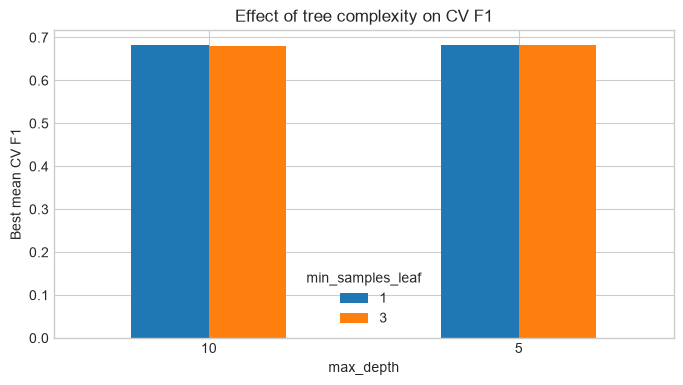

In [9]:
# Random Forestのパラメータ探索結果をDataFrameに変換する
rf_cv_results = pd.DataFrame(rf_grid.cv_results_)
# 木の深さと葉に必要な最小データ数ごとの最良平均F1を表にまとめる
rf_effect = (
    rf_cv_results.assign(
        max_depth=rf_cv_results["param_max_depth"].astype(str),
        min_samples_leaf=rf_cv_results["param_min_samples_leaf"].astype(int),
    )
    .groupby(["max_depth", "min_samples_leaf"])["mean_test_score"]
    .max()
    .unstack()
)

# 木の複雑さと交差検証F1の関係を棒グラフで表示する
ax = rf_effect.plot(kind="bar", figsize=(8, 4))
# グラフのタイトル・軸ラベル・凡例を設定する
ax.set(
    title="Effect of tree complexity on CV F1",
    xlabel="max_depth",
    ylabel="Best mean CV F1",
)
ax.legend(title="min_samples_leaf")
plt.xticks(rotation=0)
plt.show()

## 4. テストデータによる性能比較

CVはハイパーパラメータの選択にのみ用い、最終的な性能は一度も学習に使用していないテストデータで評価する。クラス不均衡があるためAccuracyだけで判断せず、陽性クラスのPrecision、Recall、F1、ROC-AUCを併記する。

In [10]:
# 比較する4種類のモデルを辞書にまとめる
models = {
    "kNN default": knn_default,
    "kNN tuned": knn_tuned,
    "RF default": rf_default,
    "RF tuned": rf_tuned,
}
# 各モデルの交差検証F1を辞書にまとめる
cv_f1 = {
    "kNN default": knn_default_cv_scores.mean(),
    "kNN tuned": knn_grid.best_score_,
    "RF default": rf_default_cv_scores.mean(),
    "RF tuned": rf_grid.best_score_,
}

# 1つのモデルについて予測を行い、各評価指標を返す関数
def evaluate_classifier(name, model, X_eval, y_eval):
    # 0または1の予測クラスを取得する
    y_pred = model.predict(X_eval)
    # ROC-AUC計算用に、陽性クラスである確率を取得する
    y_score = model.predict_proba(X_eval)[:, 1]
    # モデル名と各評価指標を辞書として返す
    return {
        "model": name,
        "CV F1": cv_f1[name],
        "Accuracy": accuracy_score(y_eval, y_pred),
        "Precision": precision_score(y_eval, y_pred, zero_division=0),
        "Recall": recall_score(y_eval, y_pred, zero_division=0),
        "F1": f1_score(y_eval, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, y_score),
    }

# 全モデルをテストデータで評価し、比較表を作成する
comparison = pd.DataFrame(
    [evaluate_classifier(name, model, X_test, y_test) for name, model in models.items()]
).set_index("model")

# 小数点以下3桁で表示し、各指標の最大値を緑色で強調する
display(comparison.style.format("{:.3f}").highlight_max(axis=0, color="#c6efce"))

,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
model,,,,,,
kNN default,0.588,0.701,0.583,0.519,0.549,0.740
kNN tuned,0.609,0.747,0.660,0.574,0.614,0.774
RF default,0.633,0.773,0.711,0.593,0.646,0.815
RF tuned,0.683,0.753,0.614,0.796,0.694,0.825


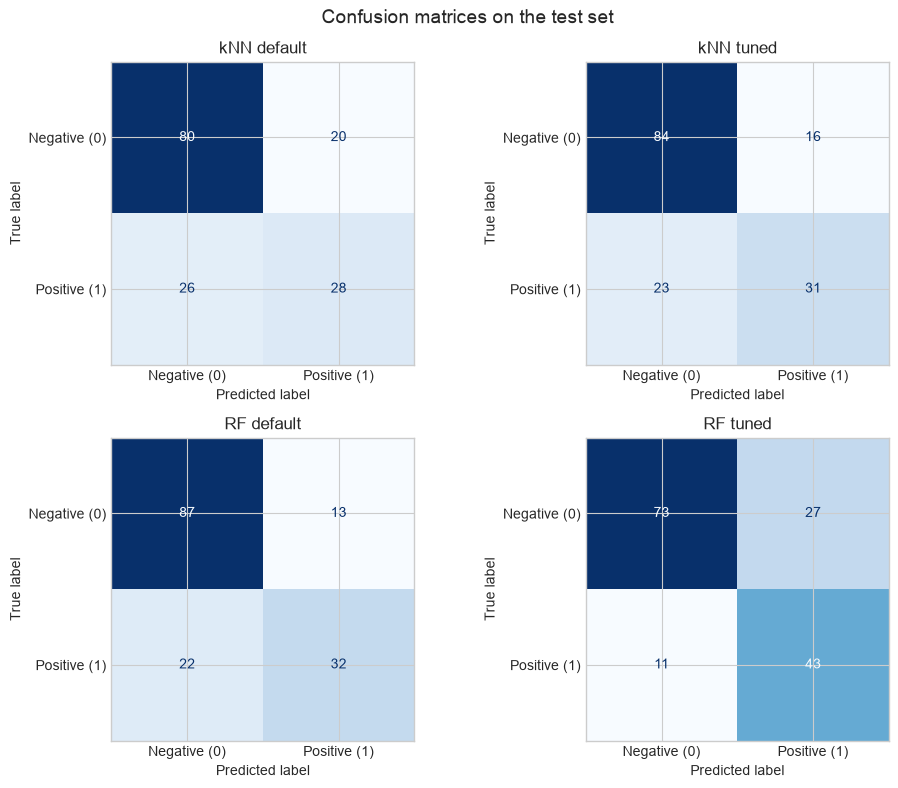

In [11]:
# 4モデル分の混同行列を並べる2×2の描画領域を作る
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# 各モデルについてテストデータの混同行列を描画する
for ax, (name, model) in zip(axes.ravel(), models.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=["Negative (0)", "Positive (1)"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)
# 全体タイトルとレイアウトを調整して表示する
fig.suptitle("Confusion matrices on the test set", fontsize=14)
plt.tight_layout()
plt.show()

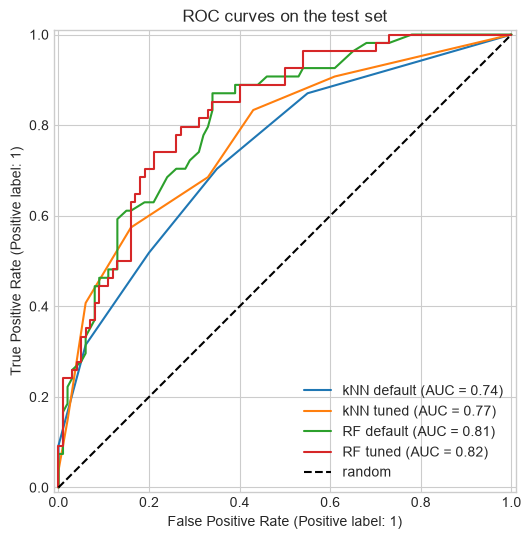

In [12]:
# ROC曲線を描くための描画領域を作る
fig, ax = plt.subplots(figsize=(7, 6))
# 各モデルのROC曲線をテストデータから描画する
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
# ランダム予測を表す対角線を追加する
ax.plot([0, 1], [0, 1], "k--", label="random")
# タイトルと凡例を設定して表示する
ax.set_title("ROC curves on the test set")
ax.legend(loc="lower right")
plt.show()

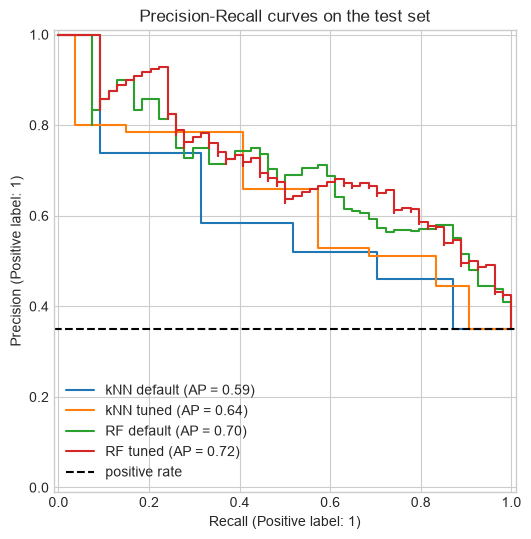

In [13]:
# Precision-Recall曲線を描くための描画領域を作る
fig, ax = plt.subplots(figsize=(7, 6))
# 各モデルのPrecision-Recall曲線をテストデータから描画する
for name, model in models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
# 基準となるテストデータの陽性率を水平線で表示する
ax.axhline(y_test.mean(), color="k", linestyle="--", label="positive rate")
# タイトルと凡例を設定して表示する
ax.set_title("Precision-Recall curves on the test set")
ax.legend(loc="lower left")
plt.show()

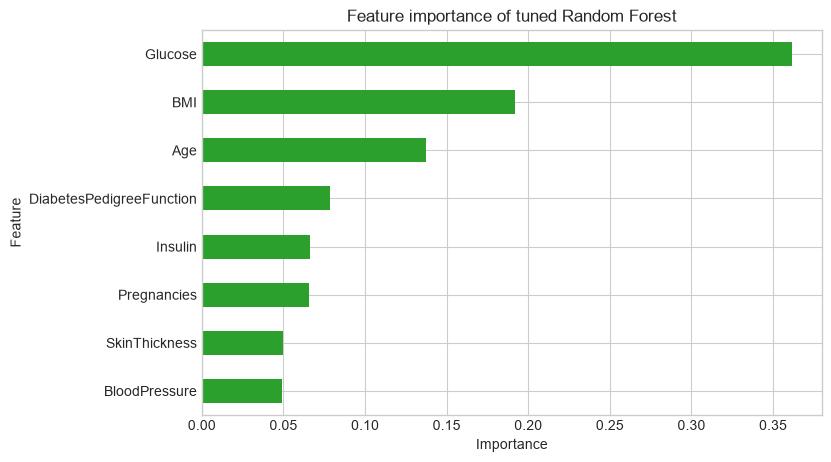

,importance
Glucose,0.362
BMI,0.192
Age,0.137
DiabetesPedigreeFunction,0.079
Insulin,0.066
Pregnancies,0.066
SkinThickness,0.050
BloodPressure,0.049


In [14]:
# 調整済みRandom Forestから各特徴量の重要度を取得し、昇順に並べる
rf_importance = pd.Series(
    rf_tuned.feature_importances_, index=X.columns, name="importance"
).sort_values()

# 特徴量の重要度を横棒グラフで表示する
ax = rf_importance.plot(kind="barh", figsize=(8, 5), color="tab:green")
ax.set(title="Feature importance of tuned Random Forest", xlabel="Importance", ylabel="Feature")
plt.show()
# 重要度が高い順の数値表も表示する
display(rf_importance.sort_values(ascending=False).to_frame().style.format("{:.3f}"))

## 5. 結果の考察

以下では、実行結果からテストF1が最大のモデルと、各手法におけるチューニング前後の変化を自動的にまとめる。テストデータは154件と限られるため、わずかな差を一般的な優劣として断定せず、CVの平均とばらつきもあわせて判断する必要がある。

In [15]:
# テストF1が最も高いモデル名と、その評価結果を取得する
best_model_name = comparison["F1"].idxmax()
best_row = comparison.loc[best_model_name]

# チューニング前後でF1がどれだけ変化したかを計算する
knn_delta = comparison.loc["kNN tuned", "F1"] - comparison.loc["kNN default", "F1"]
rf_delta = comparison.loc["RF tuned", "F1"] - comparison.loc["RF default", "F1"]

# 計算結果を埋め込んだ考察文をMarkdown形式で作成する
summary = f"""
### まとめ

- テストF1が最も高かったのは **{best_model_name}**（F1={best_row['F1']:.3f}, Precision={best_row['Precision']:.3f}, Recall={best_row['Recall']:.3f}, ROC-AUC={best_row['ROC-AUC']:.3f}）である。
- kNNのチューニングによるテストF1の変化は **{knn_delta:+.3f}** であった。選択された設定は `{knn_grid.best_params_}` である。
- Random ForestのチューニングによるテストF1の変化は **{rf_delta:+.3f}** であった。選択された設定は `{rf_grid.best_params_}` である。
- チューニングはCV上でF1を最大化するが、有限のテストデータでは必ずしも全指標が改善するとは限らない。特にPrecisionとRecallのどちらが変化したかを混同行列とPrecision-Recall曲線で確認する必要がある。
- 今回は0値をそのまま用いた。実運用を想定する場合は、医学的に不自然な0を欠損値として扱い、CV内で補完する方法との比較が必要である。
"""
# 作成した考察文をNotebook上に表示する
display(Markdown(summary))


### まとめ

- テストF1が最も高かったのは **RF tuned**（F1=0.694, Precision=0.614, Recall=0.796, ROC-AUC=0.825）である。
- kNNのチューニングによるテストF1の変化は **+0.065** であった。選択された設定は `{'model__n_neighbors': 7, 'model__p': 2, 'model__weights': 'uniform'}` である。
- Random ForestのチューニングによるテストF1の変化は **+0.047** であった。選択された設定は `{'class_weight': 'balanced', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 300}` である。
- チューニングはCV上でF1を最大化するが、有限のテストデータでは必ずしも全指標が改善するとは限らない。特にPrecisionとRecallのどちらが変化したかを混同行列とPrecision-Recall曲線で確認する必要がある。
- 今回は0値をそのまま用いた。実運用を想定する場合は、医学的に不自然な0を欠損値として扱い、CV内で補完する方法との比較が必要である。
